In [1]:
import sys, os
sys.path.append(os.getcwd().split('src')[0] + 'src')
from utils import *
from simulations.src import *

In [2]:
manifold_type = 'S2'; manifold = get_manifold(manifold_type)


n_samples_ls = [100, 500, 1000, 2500, 5000, 7500, 10000]

G_sampler_ls = [
    get_G_class(manifold_type, sampler, name, params) for sampler, name, params 
        in [
            (uniform_sampler, 'uniform', None),
            (multimodal_sampler, '1-modal', {'tau2' : 0.05, 'num_modes' : 1}),
            (multimodal_sampler, '4-modal', {'tau2' : 0.01, 'num_modes' : 4}),
            (equator_sampler, 'equator', {'tau2' : 0.001})         
        ]
    ]

sigma2 = 0.1

test_size = 1000
num_oracle_samples = 2500

NMC = 10

test_size = 1000
num_oracle_samples = 10000

M_grid =  [1,2,3,4,5,6,7,8,9,10, 12, 15, 30, 50]
rho_grid = [0.5, 0.25, 1e-1, 0.05, 0.025, 1e-2, 1e-3, 1e-4, 1e-5, 1e-6, 1e-7, 1e-8]


In [19]:
results = pd.concat([
    converenge_rate_experiment(manifold_type, G, n_samples_ls, M_grid, rho_grid, sigma2, test_size, num_oracle_samples, NMC)
    for G in G_sampler_ls])

G="uniform", σ²=0.1:   0%|          | 0/1680 [00:00<?, ?it/s]

G="1-modal", σ²=0.1:   0%|          | 0/1680 [00:00<?, ?it/s]

G="4-modal", σ²=0.1:   0%|          | 0/1680 [00:00<?, ?it/s]

G="equator", σ²=0.1:   0%|          | 0/1680 [00:00<?, ?it/s]

In [20]:
filepath = 'data/{}/rate_{}.csv'.format(manifold_type,manifold_type)

if os.path.exists(filepath):
    print(f"'{filepath}' already exists.")
    choice = input("Choose an option — [c] concatenate, [o] overwrite, [n] do nothing: ").strip().lower()
    
    if choice == 'c':
        existing = pd.read_csv(filepath)
        combined = pd.concat([existing, results], ignore_index=True).drop_duplicates()
        combined.to_csv(filepath, index=False)
        print(f"Files concatenated and saved ({len(combined)} rows, duplicates removed).")
    elif choice == 'o':
        results.to_csv(filepath, index=False)
        print("File overwritten.")
    elif choice == 'n':
        print("No changes made.")
    else:
        print("Invalid input. No changes made.")
else:
    results.to_csv(filepath, index=False)
    print(f"File saved to '{filepath}'.")

'data/S2/rate_S2.csv' already exists.
Files concatenated and saved (4704 rows, duplicates removed).


In [28]:
cv_selected_M = []
M_grid =  [1,2,3,4,5,6,7,8,9,10]

total = len(G_sampler_ls) * len(n_samples_ls)
with tqdm(total=total, desc="Density CV over (G, n)", unit="task") as pbar:
    for G in G_sampler_ls:
        for n in n_samples_ls:
            Theta = G.sample(n)
            X = manifold.random_riemannian_normal(Theta, 1 / sigma2, n)

            Mstar = select_M_by_DensityKFoldCV(manifold_type, X, M_grid, n_splits=5, earlystop=False)

            cv_selected_M.append({
                "G": G.name,
                "sigma2": sigma2,
                "n": n,
                "M": Mstar["cv"],
                "M (AIC)": Mstar["AIC"],
                "M (BIC)": Mstar["BIC"],
            })

            pbar.set_postfix(G=G.name, n=n, M=Mstar["cv"])
            pbar.update(1)
cv_selected_M_df = pd.DataFrame(cv_selected_M)
display(cv_selected_M_df)
cv_selected_M_df.to_csv('data/{}/cv_selected_M.csv'.format(manifold_type), index=False)

Density CV over (G, n): 100%|██████████| 28/28 [11:26<00:00, 24.51s/task, G=equator, M=8, n=1e+4] 


,G,sigma2,n,M,M (AIC),M (BIC)
0,uniform,0.1,100,9,1,1
1,uniform,0.1,500,2,1,1
2,uniform,0.1,1000,1,1,1
3,uniform,0.1,2500,9,1,1
4,uniform,0.1,5000,3,1,1
5,uniform,0.1,7500,2,1,1
6,uniform,0.1,10000,1,1,1
7,1-modal,0.1,100,4,3,2
8,1-modal,0.1,500,4,4,3
9,1-modal,0.1,1000,5,4,4


In [29]:
cv_selected_M_df.to_csv('data/{}/cv_selected_M.csv'.format(manifold_type), index=False)


------

In [37]:
results = pd.read_csv(filepath)
results = results[results.rho < 0.1]

In [49]:
total = len(G_sampler_ls)* len(n_samples_ls)
cv_selected_M = []
for G in G_sampler_ls:
    for n in n_samples_ls:
        cv_selected_M.append({
            "G": G.name,
            "sigma2": sigma2,
            "n": n,
            "M": int(np.log(n)-1)
        })
cv_selected_M_df = pd.DataFrame(cv_selected_M)

In [50]:
plot_mcratesims_interactive(manifold_type, results, G_sampler_ls, selected_NMC=NMC, cv_selected_M_df = cv_selected_M_df)


Output()

-----

/var/folders/4l/9wthfjb520bf_3mctz_1csd00000gn/T/ipykernel_16083/2488494644.py:43: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


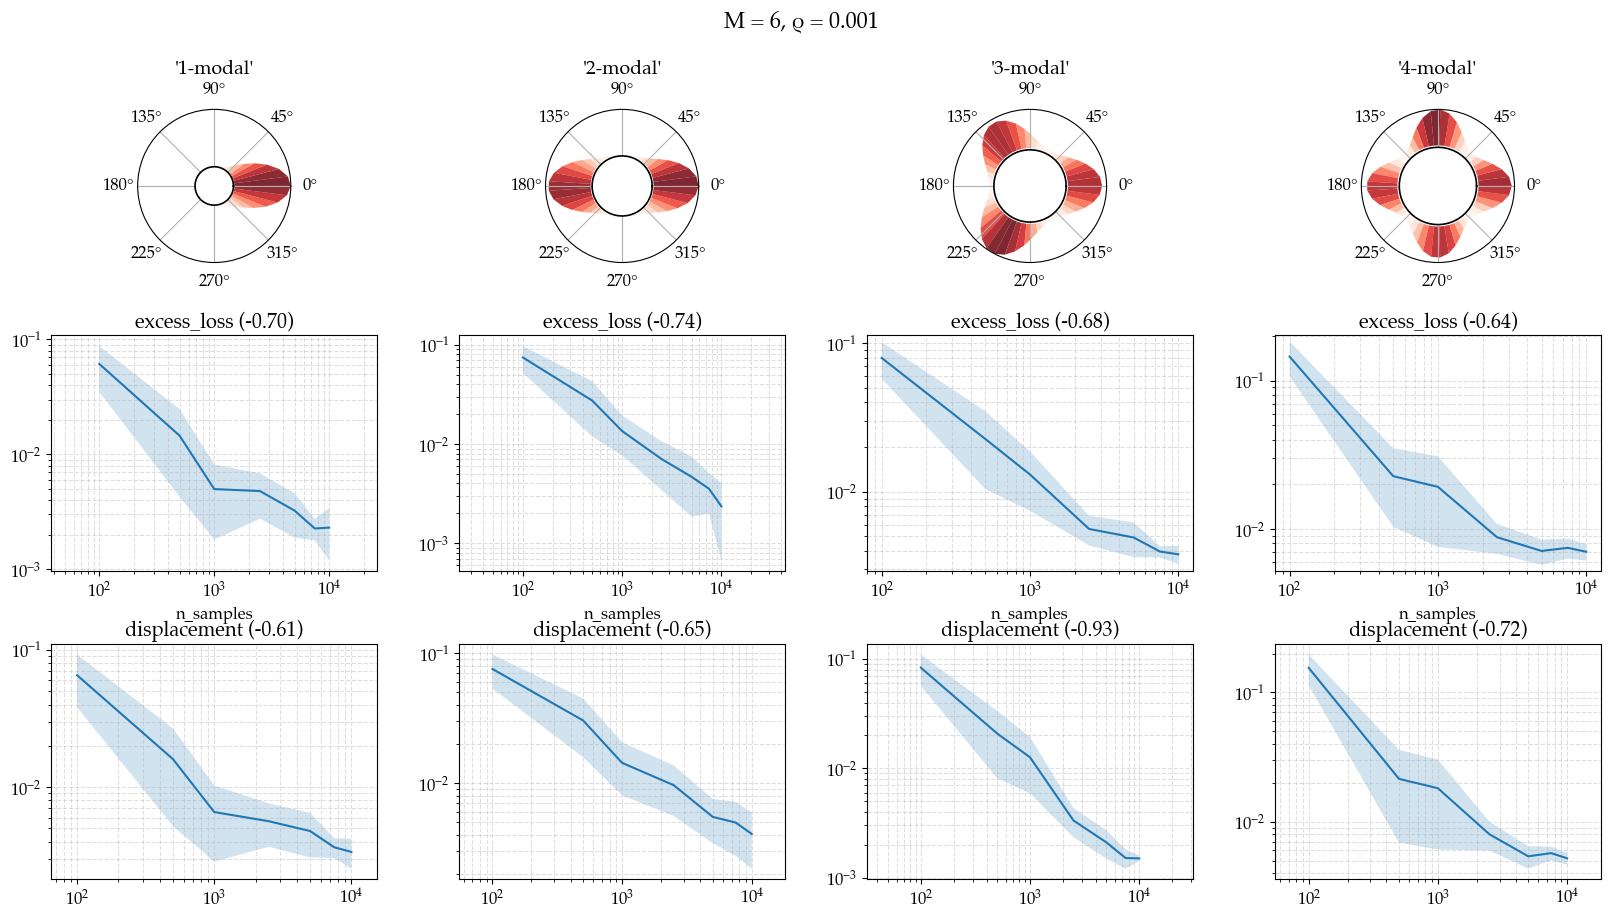

In [ ]:
selected_G = G_sampler_ls[0]
selected_M = M_grid[5]
selected_rho = rho_grid[6]
# plot_mcratesims(manifold_type, results, G_sampler_ls, selected_M, selected_rho, NMC, savefig=None)
